In [206]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [207]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [208]:
df_train

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [209]:
df_test

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4
...,...,...,...,...,...,...,...,...,...,...,...,...
725,2915,361,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3
726,2916,362,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2
727,2917,363,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9
728,2918,364,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5


In [210]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [211]:
df_train.isna().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [212]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [213]:
X_train = df_train.drop('rainfall', axis=1)
y_train = df_train['rainfall']
X_test = df_test.copy()

In [214]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [215]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [216]:
from keras.utils import to_categorical

In [217]:
y_train = to_categorical(y_train,num_classes=2)

In [218]:
y_train.shape

(2190, 2)

In [219]:
from keras import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [220]:
X_train.shape

(2190, 11)

In [178]:
model = Sequential()
model.add(Dense(units=16, activation='relu', input_shape=(11, )))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=2, activation='softmax'))

C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [158]:
# model = Sequential()
# model.add(Dense(units=96, activation='relu', input_shape=(11, )))
# model.add(Dense(units=64, activation='relu'))
# model.add(Dense(units=32, activation='relu'))
# model.add(Dense(units=16, activation='relu'))
# model.add(Dense(units=8, activation='relu'))
# model.add(Dense(units=4, activation='relu'))
# model.add(Dense(units=2, activation='softmax'))

C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [179]:
model.compile(optimizer = Adam(learning_rate = 0.001),loss = 'binary_crossentropy', metrics=['accuracy'])

In [160]:
# model.fit(X_train,y_train, validation_split = 0.30, epochs = 100)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7808 - loss: 0.5199 - val_accuracy: 0.8630 - val_loss: 0.3787
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8637 - loss: 0.3682 - val_accuracy: 0.8676 - val_loss: 0.3467
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8682 - loss: 0.3468 - val_accuracy: 0.8737 - val_loss: 0.3452
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8650 - loss: 0.3374 - val_accuracy: 0.8661 - val_loss: 0.3463
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8689 - loss: 0.3334 - val_accuracy: 0.8630 - val_loss: 0.3418
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8702 - loss: 0.3285 - val_accuracy: 0.8600 - val_loss: 0.3416
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8702 - loss: 0.3252 - val_accuracy: 0.8691 - val_loss: 0.3402
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8708 - loss: 0.3163 - val_accuracy: 0.8630 - 

In [180]:
model.fit(X_train,y_train, validation_split = 0.30, epochs = 35)

Epoch 1/35
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7326 - loss: 0.6227 - val_accuracy: 0.7915 - val_loss: 0.5556
Epoch 2/35
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7436 - loss: 0.5443 - val_accuracy: 0.7854 - val_loss: 0.4779
Epoch 3/35
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7410 - loss: 0.4668 - val_accuracy: 0.7884 - val_loss: 0.4108
Epoch 4/35
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7808 - loss: 0.4162 - val_accuracy: 0.8447 - val_loss: 0.3771
Epoch 5/35
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8480 - loss: 0.3905 - val_accuracy: 0.8721 - val_loss: 0.3603
Epoch 6/35
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8604 - loss: 0.3733 - val_accuracy: 0.8737 - val_loss: 0.3527
Epoch 7/35
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8611 - loss: 0.3628 - val_accuracy: 0.8706 - val_loss: 0.3469
Epoch 8/35
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8624 - loss: 0.3542 - val_accuracy: 0.8706 - val_loss

In [181]:
y_pred = model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [182]:
y_pred

array([[7.8559911e-05, 9.9992144e-01],
       [1.2087265e-05, 9.9998796e-01],
       [2.6903783e-03, 9.9730968e-01],
       ...,
       [1.1143930e-03, 9.9888557e-01],
       [5.2592506e-05, 9.9994743e-01],
       [1.5549429e-02, 9.8445064e-01]], shape=(730, 2), dtype=float32)

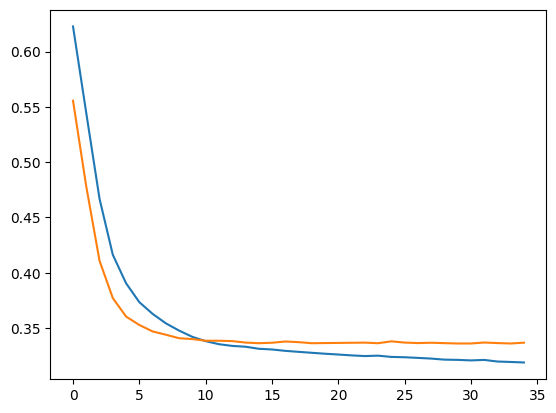

In [183]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [184]:
df_sub = pd.read_csv('sample_submission.csv')

In [185]:
df_sub['rainfall'] = y_pred

In [186]:
df_sub.to_csv('sub2.csv',index = False, index_label= False)